In this file, Im just trying to run the code on my local machine with code that would be more or less same, when run on cloud as well. This file fetches a few datapoints from the DBLP dataset using the DBLP API, and creates a hypergraph using bipartite graphs as mentioned in the report. It processes the raw fetched data using pyspark dataframe and creates the neptune csvs that will be then used to create the graph. This file creates the graph and plots it.

In [1]:
import numpy as np
import os
import pandas as pd
import time
import xml.etree.ElementTree as ET
from xml.dom import minidom
import requests

# 1. Query a few rows from the DBLP dataset using the API and store in local

In [10]:
VENUE_QUERIES = [
    ("NeurIPS 2023", 100),
    ("ICML 2023",     80),
    ("SIGMOD 2023",   60),
]
MIN_AUTHORS = 2
OUTPUT_XML  = "data/sample_dblp.xml"

In [6]:
import requests
import time
import xml.etree.ElementTree as ET

def fetch_publications(query, max_hits, retries=5, backoff=2.0):
    url = "https://dblp.org/search/publ/api"
    params = {"q": query, "h": max_hits, "f": 0, "format": "xml"}
    
    for attempt in range(retries):
        try:
            resp = requests.get(url, params=params, timeout=30)
            resp.raise_for_status()
            break  # success
        except requests.HTTPError as e:
            if resp.status_code == 503 and attempt < retries - 1:
                wait = backoff * (2 ** attempt)   # 2s, 4s, 8s, 16s ...
                print(f"  503 on '{query}', retrying in {wait:.0f}s "
                      f"(attempt {attempt+1}/{retries})")
                time.sleep(wait)
            else:
                raise   # give up after max retries or non-503 error

    root = ET.fromstring(resp.content)
    pubs = []
    for hit in root.findall(".//hit"):
        info = hit.find("info")
        if info is None: continue
        authors_el = info.find("authors")
        if authors_el is None: continue
        authors = [a.text.strip() for a in authors_el.findall("author") if a.text]
        if len(authors) < MIN_AUTHORS: continue
        key   = (info.findtext("key")   or "").strip()
        title = (info.findtext("title") or "").strip()
        year  = (info.findtext("year")  or "").strip()
        venue = (info.findtext("venue") or "").strip()
        if key and title:
            pubs.append({"key": key, "title": title, "year": year,
                         "venue": venue, "authors": authors})
    return pubs

In [7]:
all_pubs = []
seen_keys = set()
for query, max_hits in VENUE_QUERIES:
    pubs = fetch_publications(query, max_hits)
    for p in pubs:
        if p["key"] not in seen_keys:
            seen_keys.add(p["key"])
            all_pubs.append(p)
    print(f"{query}: {len(pubs)} pubs fetched")
    time.sleep(1.5)

print(f"\nTotal unique pubs: {len(all_pubs)}")

  503 on 'NeurIPS 2023', retrying in 2s (attempt 1/5)
  503 on 'NeurIPS 2023', retrying in 4s (attempt 2/5)
  503 on 'NeurIPS 2023', retrying in 8s (attempt 3/5)
  503 on 'NeurIPS 2023', retrying in 16s (attempt 4/5)
NeurIPS 2023: 100 pubs fetched
ICML 2023: 74 pubs fetched


HTTPError: 500 Server Error: Internal Server Error for url: https://dblp.org/search/publ/api?q=SIGMOD+2023&h=60&f=0&format=xml

Ive got 174, thats good enough

In [9]:
print(f"\nTotal unique pubs: {len(all_pubs)}")


Total unique pubs: 174


In [11]:
# Save as DBLP-like XML
# <author> repeated as siblings (not nested under <authors>) so that
# spark-xml can read them as ArrayType(StringType) with an explicit schema
root = ET.Element("dblp")
for p in all_pubs:
    el = ET.SubElement(root, "publication")
    ET.SubElement(el, "key").text   = p["key"]
    ET.SubElement(el, "title").text = p["title"]
    ET.SubElement(el, "year").text  = p["year"]
    ET.SubElement(el, "venue").text = p["venue"]
    for a in p["authors"]:
        ET.SubElement(el, "author").text = a

pretty = minidom.parseString(ET.tostring(root)).toprettyxml(indent="  ")
with open(OUTPUT_XML, "w", encoding="utf-8") as f:
    f.write(pretty)
print(f"Saved → {OUTPUT_XML}  ({os.path.getsize(OUTPUT_XML)//1024} KB)")

Saved → data/sample_dblp.xml  (77 KB)


# 2. PySpark preprocessing and then Saving as Neptune Bulk Loader CSVs

In [2]:
import glob, shutil
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, ArrayType

In [ ]:
# os.environ["HADOOP_HOME"] = r"D:\hadoop"
# os.environ["PATH"] += r";D:\hadoop\bin"

In [3]:
import sys
os.environ["HADOOP_HOME"] = r"D:\hadoop"
os.environ["PATH"] += r";D:\hadoop\bin"
os.environ["PYSPARK_PYTHON"] = sys.executable       # points Spark to your current Python
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [4]:
spark = (SparkSession.builder
    .appName("DBLP-Hypergraph")
    .config("spark.jars.packages", "com.databricks:spark-xml_2.12:0.18.0")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")


In [ ]:
# # Explicit schema forces `author` to always be a list,
# # even for single-author records
# schema = StructType([
#     StructField("key",    StringType(),            True),
#     StructField("title",  StringType(),            True),
#     StructField("year",   StringType(),            True),
#     StructField("venue",  StringType(),            True),
#     StructField("author", ArrayType(StringType()), True),
# ])

In [5]:
# this wont work because I dont have spark-xml JAR
# df = (spark.read.format("xml")
#       .option("rowTag", "publication")
#       .schema(schema)
#       .load("data\\sample_dblp.xml"))

# Ill load using pandas instead
# Parse XML with Python instead of spark-xml
tree = ET.parse("data/sample_dblp.xml")
records = []
for pub in tree.getroot().findall("publication"):
    authors = [a.text.strip() for a in pub.findall("author") if a.text]
    if len(authors) < 2:
        continue
    records.append({
        "key":   (pub.findtext("key")   or "").strip(),
        "title": (pub.findtext("title") or "").strip(),
        "year":  (pub.findtext("year")  or "").strip(),
        "venue": (pub.findtext("venue") or "").strip(),
        "authors": authors,
    })

# Load into Spark as a pandas-backed dataframe — no spark-xml needed
pandas_df = pd.DataFrame(records)
df = spark.createDataFrame(pandas_df)
df.show(5)

+--------------------+--------------------+----+------------+--------------------+
|                 key|               title|year|       venue|             authors|
+--------------------+--------------------+----+------------+--------------------+
|      conf/nips/2023|Advances in Neura...|2023|     NeurIPS|[Alice Oh, Trista...|
|      conf/ml4h/2023|Machine Learning ...|2023|ML4H@NeurIPS|[Stefan Hegselman...|
|    conf/icbinb/2023|Proceedings on "I...|2023|      ICBINB|[Javier Antorán, ...|
|conf/ml4h/Hegselm...|Machine Learning ...|2023|ML4H@NeurIPS|[Stefan Hegselman...|
|  conf/neurreps/2023|NeurIPS Workshop ...|2023|    NeurReps|[Sophia Sanborn, ...|
+--------------------+--------------------+----+------------+--------------------+
only showing top 5 rows


In [7]:
# dropping nulls, require ≥2 authors, deduplicate
df = (df
      .filter(F.col("key").isNotNull() & F.col("authors").isNotNull())
      .filter(F.size("authors") >= 2)
      .dropDuplicates(["key"])
      .withColumn("authors", F.transform("authors", lambda a: F.trim(a))))


In [11]:
# Stable IDs via MD5 of content
df = df.withColumn("paper_id", F.concat(F.lit("p_"), F.md5("key")))

In [13]:
# Explode to one row per (paper, author) pair
edges_raw = (df
    .select("paper_id", "key", "title", "year", "venue",
            F.explode("authors").alias("author_name"))
    .withColumn("author_id", F.concat(F.lit("a_"), F.md5("author_name"))))

edges_raw

DataFrame[paper_id: string, key: string, title: string, year: string, venue: string, author_name: string, author_id: string]

### Building the authors, papers and edges Neptune CSVs

In [14]:
author_nodes = (edges_raw
    .select(F.col("author_id").alias("~id"),
            F.lit("authors").alias("~label"),
            F.col("author_name").alias("name:String"))
    .distinct())

In [15]:
paper_nodes = (df
    .select(F.col("paper_id").alias("~id"),
            F.lit("paper").alias("~label"),
            F.col("title").alias("title:String"),
            F.col("year").alias("year:String"),
            F.col("venue").alias("venue:String"),
            F.col("key").alias("dblp_key:String"))
    .distinct())

In [16]:
edges_df = (edges_raw
    .select(F.concat(F.lit("e_"), F.md5(
                F.concat("author_id", F.lit("|"), "paper_id")
            )).alias("~id"),
            F.col("author_id").alias("~from"),
            F.col("paper_id").alias("~to"),
            F.lit("authored").alias("~label"))
    .distinct())

In [ ]:
def save_csv(df, final_path):
    '''
        Since spark doesnt save into a single directory, this function collects all and saves in one consolidated csv file
    '''
    tmp = final_path + "_tmp"
    df.coalesce(1).write.mode("overwrite").option("header", True).csv(tmp)
    part = glob.glob(f"{tmp}/part-*.csv")[0]
    shutil.copy(part, final_path)
    shutil.rmtree(tmp)

# NOTE: THIS FUNCTION DOES NOT RUN ON MY LOCAL MACHINE, SO IM JUST USING THE DIRECT PD.TO_CSV function instead

In [19]:
os.makedirs("data/neptune_csvs", exist_ok=True)
author_nodes.toPandas().to_csv("data/neptune_csvs/author_nodes.csv", index=False)
paper_nodes.toPandas().to_csv("data/neptune_csvs/paper_nodes.csv", index=False)
edges_df.toPandas().to_csv("data/neptune_csvs/edges.csv", index=False)

In [21]:
print(f"Authors : {author_nodes.count()}")
print(f"Papers  : {paper_nodes.count()}")
print(f"Edges   : {edges_df.count()}")
print("Saved → output/author_nodes.csv, paper_nodes.csv, edges.csv")

Authors : 986
Papers  : 174
Edges   : 1121
Saved → output/author_nodes.csv, paper_nodes.csv, edges.csv


# 3. Visualizing the hypergraph

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [5]:
authors = pd.read_csv("data/neptune_csvs/author_nodes.csv")
papers  = pd.read_csv("data/neptune_csvs/paper_nodes.csv")
edges   = pd.read_csv("data/neptune_csvs/edges.csv")

In [6]:
# Build bipartite graph
G = nx.Graph()
for _, r in authors.iterrows():
    G.add_node(r["~id"], bipartite=0, name=r["name:String"])
for _, r in papers.iterrows():
    G.add_node(r["~id"], bipartite=1, title=r["title:String"])
for _, r in edges.iterrows():
    G.add_edge(r["~from"], r["~to"])

In [7]:
author_ids = set(authors["~id"])
paper_ids = set(papers["~id"])
author_degs = [G.degree(n) for n in author_ids]   # papers per author
paper_degs = [G.degree(n) for n in paper_ids]    # authors per paper (hyperedge size)

In [8]:
comps = list(nx.connected_components(G))
lcc = max(comps, key=len)
proj = nx.projected_graph(G, author_ids)      # co-authorship projection

In [9]:
print(f"Authors                   : {len(author_ids):,}")
print(f"Papers (hyperedges)       : {len(paper_ids):,}")
print(f"Authorship edges          : {G.number_of_edges():,}")
print(f"Avg hyperedge size        : {np.mean(paper_degs):.2f}")
print(f"Avg author degree         : {np.mean(author_degs):.2f}")
print(f"Connected components      : {len(comps)}")
print(f"Largest CC (% of nodes)   : {len(lcc)/G.number_of_nodes():.1%}")
print(f"Co-authorship edges       : {proj.number_of_edges():,}")
print(f"Avg clustering coeff.     : {nx.average_clustering(proj):.4f}")

Authors                   : 986
Papers (hyperedges)       : 174
Authorship edges          : 1,121
Avg hyperedge size        : 6.44
Avg author degree         : 1.14
Connected components      : 142
Largest CC (% of nodes)   : 11.3%
Co-authorship edges       : 7,033
Avg clustering coeff.     : 0.9636


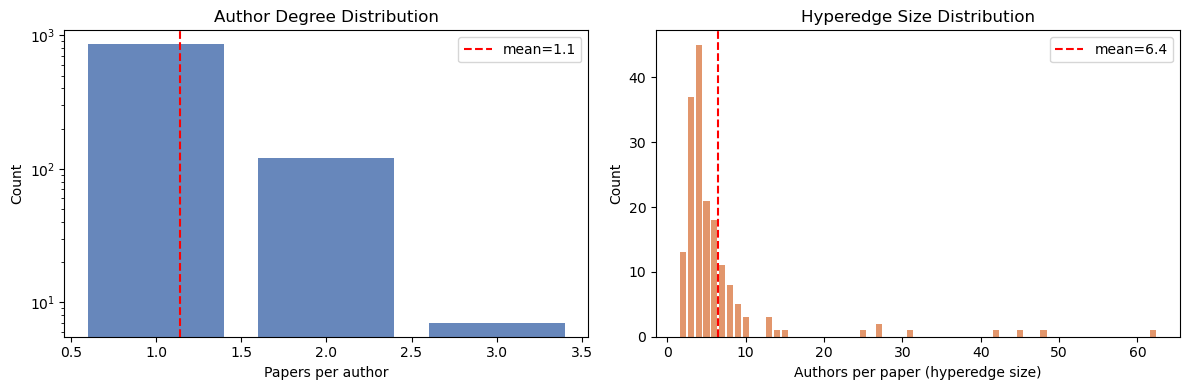

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

c = Counter(author_degs)
ax1.bar(c.keys(), c.values(), color="#4C72B0", alpha=0.85)
ax1.axvline(np.mean(author_degs), color="red", linestyle="--",
            label=f"mean={np.mean(author_degs):.1f}")
ax1.set_yscale("log"); ax1.set_xlabel("Papers per author")
ax1.set_ylabel("Count")
ax1.set_title("Author Degree Distribution")
ax1.legend()

c = Counter(paper_degs)
ax2.bar(c.keys(), c.values(), color="#DD8452", alpha=0.85)
ax2.axvline(np.mean(paper_degs), color="red", linestyle="--",
            label=f"mean={np.mean(paper_degs):.1f}")
ax2.set_xlabel("Authors per paper (hyperedge size)")
ax2.set_ylabel("Count")
ax2.set_title("Hyperedge Size Distribution")
ax2.legend()

plt.tight_layout()
plt.show()

### Bipartite Subgraph Visualization

In [11]:
# Take top-30 authors by degree + up to 4 of their papers each
top_authors = sorted(author_ids, key=lambda n: G.degree(n), reverse=True)[:30]
vis_papers  = {p for a in top_authors for p in list(G.neighbors(a))[:4]}
sub = G.subgraph(set(top_authors) | vis_papers).copy()

In [12]:
sorted_a = sorted([n for n in sub if sub.nodes[n]["bipartite"]==0], key=lambda n: -sub.degree(n))
sorted_p = sorted([n for n in sub if sub.nodes[n]["bipartite"]==1], key=lambda n: -sub.degree(n))

pos = {n: (0.0, i / max(len(sorted_a)-1,1)) for i, n in enumerate(sorted_a)}
pos.update({n: (1.0, i / max(len(sorted_p)-1,1)) for i, n in enumerate(sorted_p)})

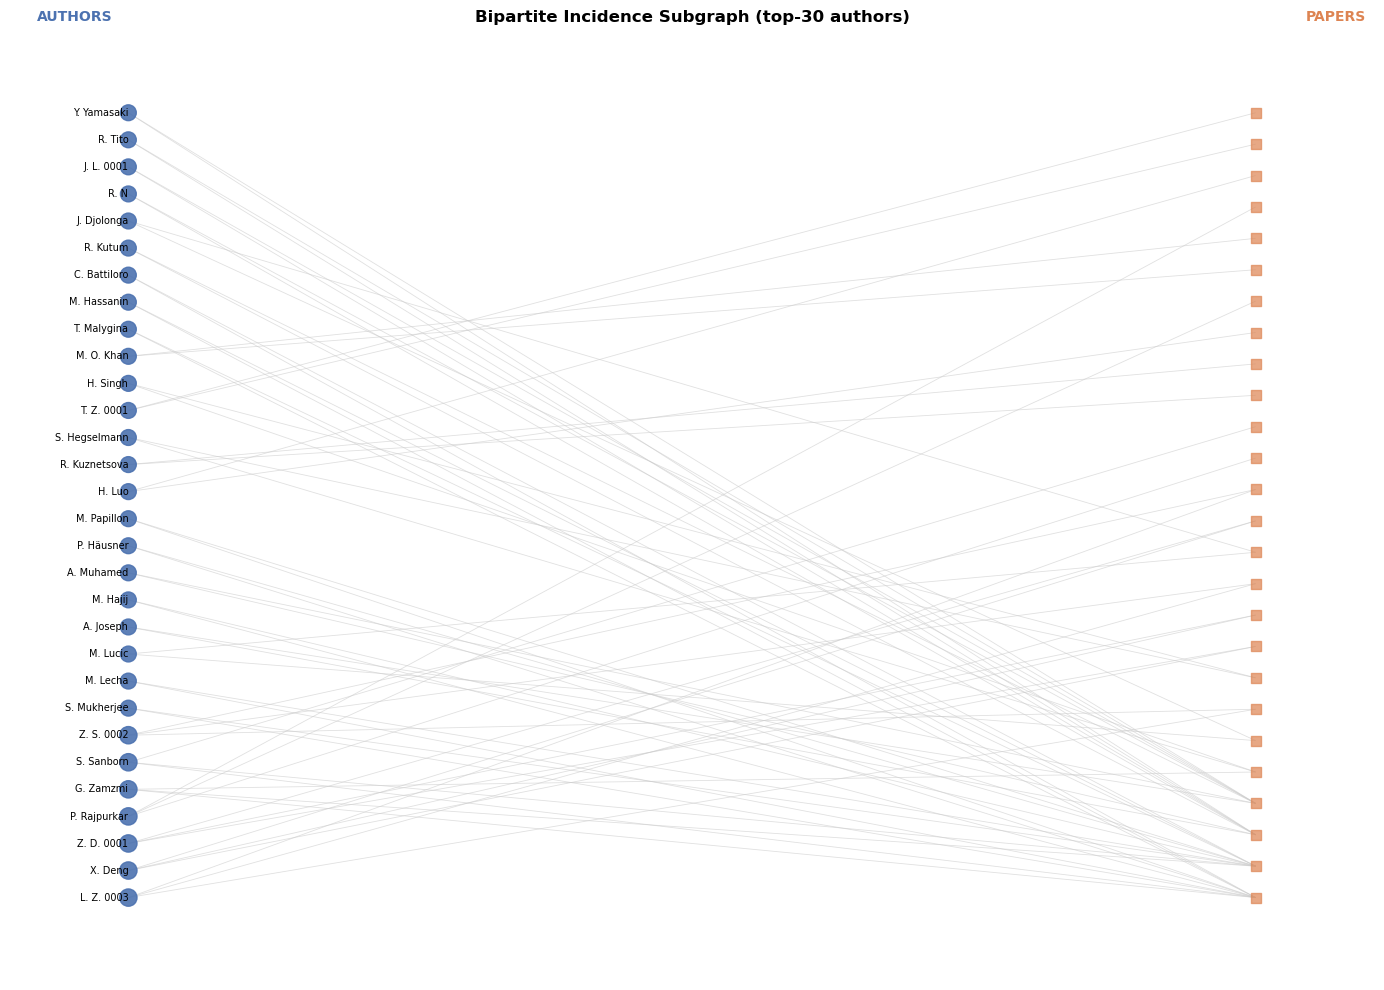

In [13]:
fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(sub, pos, ax=ax, edge_color="#cccccc", width=0.6, alpha=0.6)
nx.draw_networkx_nodes(sub, pos, nodelist=sorted_a, ax=ax,
    node_color="#4C72B0", node_size=[80+25*sub.degree(n) for n in sorted_a], alpha=0.9)
nx.draw_networkx_nodes(sub, pos, nodelist=sorted_p, ax=ax,
    node_color="#DD8452", node_size=60, node_shape="s", alpha=0.7)

labels = {n: " ".join([p[0]+"." for p in sub.nodes[n]["name"].split()[:-1]]
                       + [sub.nodes[n]["name"].split()[-1]])
          for n in sorted_a}
nx.draw_networkx_labels(sub, pos, labels=labels, ax=ax, font_size=7,
                        horizontalalignment="right")

ax.text(0.02, 1.01, "AUTHORS",  transform=ax.transAxes, color="#4C72B0", fontweight="bold")
ax.text(0.95, 1.01, "PAPERS",   transform=ax.transAxes, color="#DD8452", fontweight="bold")
ax.set_title("Bipartite Incidence Subgraph (top-30 authors)", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# Pairwise Projection of bipartite graph and comparison.

In [24]:
author_nodes = authors['~id']
author_nodes.values.shape

(986,)

In [25]:
from networkx.algorithms import bipartite
pairwise_projected_graph = bipartite.projected_graph(G, author_nodes)

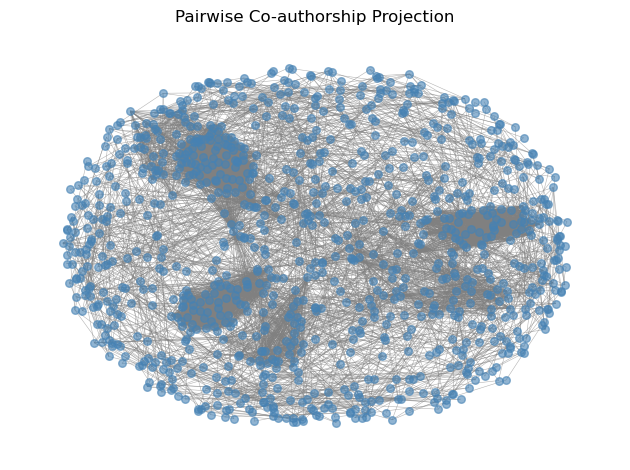

In [26]:
# For large graphs, spring layout is standard but slow — use a sample if needed
pos = nx.spring_layout(pairwise_projected_graph, seed=42, k=0.5)

nx.draw_networkx(
    pairwise_projected_graph,
    pos=pos,
    node_size=30,
    node_color="steelblue",
    edge_color="gray",
    alpha=0.6,
    with_labels=False,
    width=0.4
)

plt.title("Pairwise Co-authorship Projection")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Comparing the hypergraph and the projection.

In [31]:
# hypergraph
author_nodes_set = set(authors['~id'])
paper_nodes_set  = set(G.nodes()) - author_nodes_set

H_author_degrees    = [d for n, d in G.degree() if n in author_nodes_set]
hyperedge_sizes     = [d for n, d in G.degree() if n in paper_nodes_set] 

# projection
proj_degrees = [d for _, d in pairwise_projected_graph.degree()]

In [33]:
# edge counts
print("=== Edge Counts ===")
print(f"Bipartite incidence edges : {G.number_of_edges()}")
print(f"Pairwise projection edges : {pairwise_projected_graph.number_of_edges()}")
print(f"Edge inflation factor     : {pairwise_projected_graph.number_of_edges() / G.number_of_edges():.2f}x")

=== Edge Counts ===
Bipartite incidence edges : 1121
Pairwise projection edges : 7033
Edge inflation factor     : 6.27x


In [34]:
print("=== Author Degree Distribution ===")
print(f"Hypergraph  — mean: {np.mean(H_author_degrees):.2f}, "
      f"max: {np.max(H_author_degrees)}, median: {np.median(H_author_degrees):.1f}")
print(f"Projection  — mean: {np.mean(proj_degrees):.2f}, "
      f"max: {np.max(proj_degrees)}, median: {np.median(proj_degrees):.1f}")

=== Author Degree Distribution ===
Hypergraph  — mean: 1.14, max: 3, median: 1.0
Projection  — mean: 14.27, max: 96, median: 6.0


In [35]:
print("=== Clustering Coefficients ===")
hyper_cc = bipartite.clustering(G, nodes=author_nodes_set, mode='dot')
hyper_cc_avg = np.mean(list(hyper_cc.values()))
proj_cc_avg  = nx.average_clustering(pairwise_projected_graph)
print(f"Hypergraph (bipartite clustering) : {hyper_cc_avg:.4f}")
print(f"Projection (standard clustering)  : {proj_cc_avg:.4f}")

=== Clustering Coefficients ===
Hypergraph (bipartite clustering) : 0.9219
Projection (standard clustering)  : 0.9636


In [36]:
print("=== Connected Components ===")
G_author_subgraph = G.subgraph(author_nodes_set)  # only author nodes for fair comparison
print(f"Hypergraph author-induced components : {nx.number_connected_components(G_author_subgraph)}")
print(f"Projection components                : {nx.number_connected_components(pairwise_projected_graph)}")

=== Connected Components ===
Hypergraph author-induced components : 986
Projection components                : 142


In [37]:
print("=== Density ===")
print(f"Projection graph density : {nx.density(pairwise_projected_graph):.6f}")

=== Density ===
Projection graph density : 0.014483


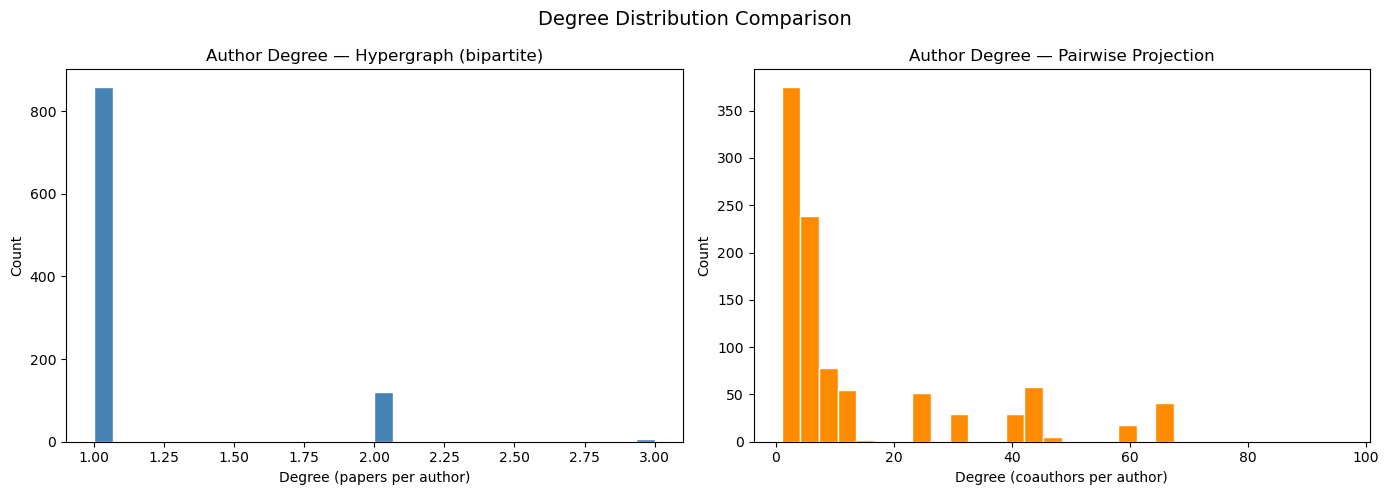

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(H_author_degrees, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Author Degree — Hypergraph (bipartite)")
axes[0].set_xlabel("Degree (papers per author)")
axes[0].set_ylabel("Count")

axes[1].hist(proj_degrees, bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Author Degree — Pairwise Projection")
axes[1].set_xlabel("Degree (coauthors per author)")
axes[1].set_ylabel("Count")

plt.suptitle("Degree Distribution Comparison", fontsize=14)
plt.tight_layout()
plt.show()